# Cassava Leaf Disease Classification — ResNet50
 

## 0. Install Dependencies

In [ ]:
%pip install tensorflow scikit-learn matplotlib seaborn -q

## 1. Imports & Reproducibility

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input  # scales to [-1,1] for ResNet
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger, Callback
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from sklearn.metrics import classification_report, confusion_matrix

tf.random.set_seed(42)
np.random.seed(42)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow: 2.19.0
GPU available: False


## 2. Custom Callback — Stop at 91% Val Accuracy

In [2]:
class StopAt91(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if logs.get("val_accuracy", 0) >= 0.91:
            print(f"\n  ✅ Reached 91% val_accuracy at epoch {epoch + 1}. Stopping.")
            self.model.stop_training = True

## 3. Config — Update Paths Here

In [3]:

DATA_DIR    = r'C:\Users\Alfred\Desktop\data'
IMG_SIZE    = (224, 224)
BATCH_SIZE  = 32
NUM_CLASSES = 4
SEED        = 42

In [4]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# ── 1. Load all images from DATA_DIR ──────────────────────────────────────────
DATA_DIR = r'C:\Users\Alfred\Desktop\data'

data_list = []
for class_name in os.listdir(DATA_DIR):
    class_path = os.path.join(DATA_DIR, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('.jpg', '.jpeg', '.png')):
            data_list.append({
                'image_path': os.path.join(class_path, img_file),
                'label': class_name
            })

df = pd.DataFrame(data_list)

# ── 2. Dataset overview ───────────────────────────────────────────────────────
print(f"Total images: {len(df)}")
print(f"Number of classes: {df['label'].nunique()}")
print("\nClass distribution:")
counts = df['label'].value_counts()
for cls, count in counts.items():
    bar = '█' * (count // 50)
    print(f"  {cls:<45} {count:>5}  {bar}")

# ── 3. Train / Val split (80% train, 20% val, stratified) ────────────────────
train_df, val_df = train_test_split(
    df,
    test_size=0.20,
    stratify=df['label'],
    random_state=42
)

print(f"\nSplit summary:")
print(f"  Train : {len(train_df)} images")
print(f"  Val   : {len(val_df)} images")
print(f"\nTrain class distribution:")
print(train_df['label'].value_counts().to_string())
print(f"\nVal class distribution:")
print(val_df['label'].value_counts().to_string())

Total images: 9726
Number of classes: 4

Class distribution:
  Cassava___brown_streak_disease                 2448  ████████████████████████████████████████████████
  Cassava___mosaic_disease                       2448  ████████████████████████████████████████████████
  Cassava___healthy                              2444  ████████████████████████████████████████████████
  Cassava___green_mottle                         2386  ███████████████████████████████████████████████

Split summary:
  Train : 7780 images
  Val   : 1946 images

Train class distribution:
label
Cassava___mosaic_disease          1958
Cassava___brown_streak_disease    1958
Cassava___healthy                 1955
Cassava___green_mottle            1909

Val class distribution:
label
Cassava___mosaic_disease          490
Cassava___brown_streak_disease    490
Cassava___healthy                 489
Cassava___green_mottle            477


## 4. Data Generators
> `preprocess_input` from `resnet50` converts pixels to the BGR mean-subtracted format that ResNet50 was trained on. Both train and val must use it.

In [5]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.8, 1.2],
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_data = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=True,
    seed=SEED
)

val_data = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

print(f"Classes : {train_data.class_indices}")
print(f"Train   : {train_data.samples} images")
print(f"Val     : {val_data.samples} images")

Found 7780 validated image filenames belonging to 4 classes.
Found 1946 validated image filenames belonging to 4 classes.
Classes : {'Cassava___brown_streak_disease': 0, 'Cassava___green_mottle': 1, 'Cassava___healthy': 2, 'Cassava___mosaic_disease': 3}
Train   : 7780 images
Val     : 1946 images


## 5. Class Weights (dynamic)

In [7]:
total         = train_data.samples
class_counts  = np.bincount(train_data.classes)
class_weights = {i: total / (NUM_CLASSES * c) for i, c in enumerate(class_counts)}
print("Class weights:", {k: round(v, 4) for k, v in class_weights.items()})

Class weights: {0: np.float64(0.9934), 1: np.float64(1.0189), 2: np.float64(0.9949), 3: np.float64(0.9934)}


## 6. Build Model

In [8]:
tf.keras.backend.clear_session()

base = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))
base.trainable = False

x = base.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(512, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.4)(x)
x = layers.Dense(256, activation="relu", kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.3)(x)
output = layers.Dense(NUM_CLASSES, activation="softmax", dtype="float32")(x)

model = models.Model(inputs=base.input, outputs=output)
model.compile(
    optimizer=Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print(f"Total params: {model.count_params():,}")
model.summary()


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 20s 0us/step
Total params: 24,777,348


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,777,348 (94.52 MB)

 Trainable params: 1,185,540 (4.52 MB)

 Non-trainable params: 23,591,808 (90.00 MB)

## 7. Phase 1 — Train Head Only (base frozen, 15 epochs)

In [9]:
callbacks_p1 = [
    StopAt91(),
    ModelCheckpoint("cassava_resnet50_best_phase1.keras", save_best_only=True,
                    monitor="val_accuracy", verbose=1),
    EarlyStopping(patience=5, restore_best_weights=True, monitor="val_accuracy", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-6, verbose=1),
    CSVLogger("cassava_resnet50_phase1_log.csv")
]

print("── Phase 1: training head only ──")
history_p1 = model.fit(
    train_data, validation_data=val_data,
    epochs=15, class_weight=class_weights,
    callbacks=callbacks_p1, verbose=1
)

print(f"\n✓ Phase 1 best val_accuracy: {max(history_p1.history['val_accuracy']):.4f}")

── Phase 1: training head only ──


c:\Users\Alfred\.conda\envs\pig_disease_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4087 - loss: 1.5926
Epoch 1: val_accuracy improved from -inf to 0.60894, saving model to cassava_resnet50_best_phase1.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 749s 3s/step - accuracy: 0.4089 - loss: 1.5919 - val_accuracy: 0.6089 - val_loss: 1.0432 - learning_rate: 3.0000e-04
Epoch 2/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5403 - loss: 1.2000
Epoch 2: val_accuracy improved from 0.60894 to 0.62076, saving model to cassava_resnet50_best_phase1.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 880s 4s/step - accuracy: 0.5403 - loss: 1.2000 - val_accuracy: 0.6208 - val_loss: 1.0214 - learning_rate: 3.0000e-04
Epoch 3/15
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.5672 - loss: 1.1247
Epoch 3: val_accuracy improved from 0.62076 to 0.62898, saving model to cassava_resnet50_best_phase1.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 1158s 5s/step - accuracy: 0.5672 - loss: 1.1246 - val_accuracy: 0.6290 - val_loss: 1.0021 - learning_rate:

## 8. Phase 2 — Fine-tune Top 30% of ResNet50

In [10]:
base.trainable = True
fine_tune_from = int(len(base.layers) * 0.5)
for layer in base.layers[:fine_tune_from]:
    layer.trainable = False

# Freeze BatchNorm — kept from friends' script (critical for ResNet)
for layer in base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

trainable = sum(1 for l in model.layers if l.trainable)
print(f"Trainable layers in Phase 2: {trainable}")

model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks_p2 = [
    StopAt91(),
    ModelCheckpoint("cassava_resnet50_best_phase2.keras", save_best_only=True,
                    monitor="val_accuracy", verbose=1),
    EarlyStopping(patience=7, restore_best_weights=True, monitor="val_accuracy", verbose=1),
    ReduceLROnPlateau(monitor="val_loss", factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    CSVLogger("cassava_resnet50_phase2_log.csv")
]

print("── Phase 2: fine-tuning top 30% of ResNet50 ──")
history_p2 = model.fit(
    train_data, validation_data=val_data,
    epochs=30, class_weight=class_weights,
    callbacks=callbacks_p2, verbose=1
)

print(f"\n✓ Phase 2 best val_accuracy: {max(history_p2.history['val_accuracy']):.4f}")

Trainable layers in Phase 2: 68
── Phase 2: fine-tuning top 30% of ResNet50 ──
Epoch 1/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - accuracy: 0.6433 - loss: 0.9865
Epoch 1: val_accuracy improved from -inf to 0.49024, saving model to cassava_resnet50_best_phase2.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 1930s 8s/step - accuracy: 0.6434 - loss: 0.9863 - val_accuracy: 0.4902 - val_loss: 1.2928 - learning_rate: 1.0000e-04
Epoch 2/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7088 - loss: 0.8544
Epoch 2: val_accuracy improved from 0.49024 to 0.70195, saving model to cassava_resnet50_best_phase2.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 1754s 7s/step - accuracy: 0.7088 - loss: 0.8543 - val_accuracy: 0.7020 - val_loss: 0.8678 - learning_rate: 1.0000e-04
Epoch 3/30
244/244 ━━━━━━━━━━━━━━━━━━━━ 0s 6s/step - accuracy: 0.7472 - loss: 0.7697
Epoch 3: val_accuracy improved from 0.70195 to 0.72097, saving model to cassava_resnet50_best_phase2.keras
244/244 ━━━━━━━━━━━━━━━━━━━━ 1787s 7s/step - accuracy:

## 9. Training History Plot

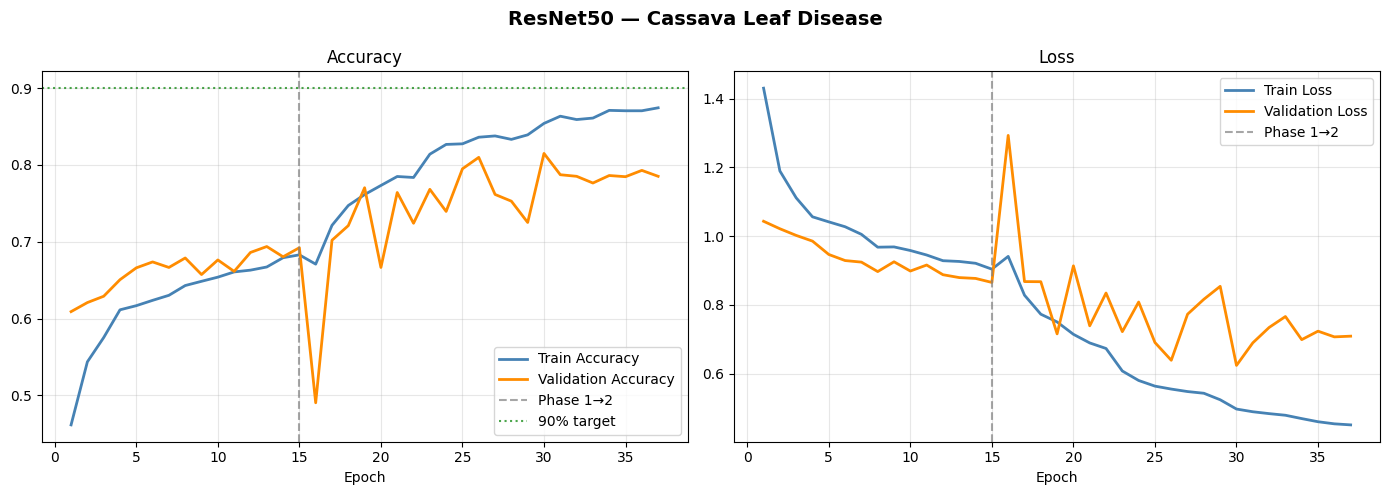

Best val_accuracy overall: 81.50%


In [11]:
acc      = history_p1.history["accuracy"]     + history_p2.history["accuracy"]
val_acc  = history_p1.history["val_accuracy"] + history_p2.history["val_accuracy"]
loss     = history_p1.history["loss"]         + history_p2.history["loss"]
val_loss = history_p1.history["val_loss"]     + history_p2.history["val_loss"]
epochs   = range(1, len(acc) + 1)
p1_end   = len(history_p1.history["accuracy"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("ResNet50 — Cassava Leaf Disease", fontsize=14, fontweight="bold")

ax1.plot(epochs, acc,     label="Train Accuracy",      color="steelblue", linewidth=2)
ax1.plot(epochs, val_acc, label="Validation Accuracy", color="darkorange", linewidth=2)
ax1.axvline(x=p1_end, color="gray",  linestyle="--", alpha=0.7, label="Phase 1→2")
ax1.axhline(y=0.90,   color="green", linestyle=":",  alpha=0.7, label="90% target")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch"); ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(epochs, loss,     label="Train Loss",      color="steelblue", linewidth=2)
ax2.plot(epochs, val_loss, label="Validation Loss", color="darkorange", linewidth=2)
ax2.axvline(x=p1_end, color="gray", linestyle="--", alpha=0.7, label="Phase 1→2")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch"); ax2.legend(); ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("training_history_resnet50.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Best val_accuracy overall: {max(val_acc)*100:.2f}%")

## 10. Save Final Model

In [12]:
model.save("cassava_resnet50_final.keras")
print("✓ Model saved: cassava_resnet50_final.keras")

✓ Model saved: cassava_resnet50_final.keras


c:\Users\Alfred\.conda\envs\pig_disease_env\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


61/61 ━━━━━━━━━━━━━━━━━━━━ 198s 3s/step
                                precision    recall  f1-score   support

Cassava___brown_streak_disease       0.91      0.88      0.89       490
        Cassava___green_mottle       0.81      0.69      0.74       477
             Cassava___healthy       0.70      0.87      0.77       489
      Cassava___mosaic_disease       0.87      0.83      0.85       490

                      accuracy                           0.82      1946
                     macro avg       0.82      0.81      0.82      1946
                  weighted avg       0.82      0.82      0.82      1946



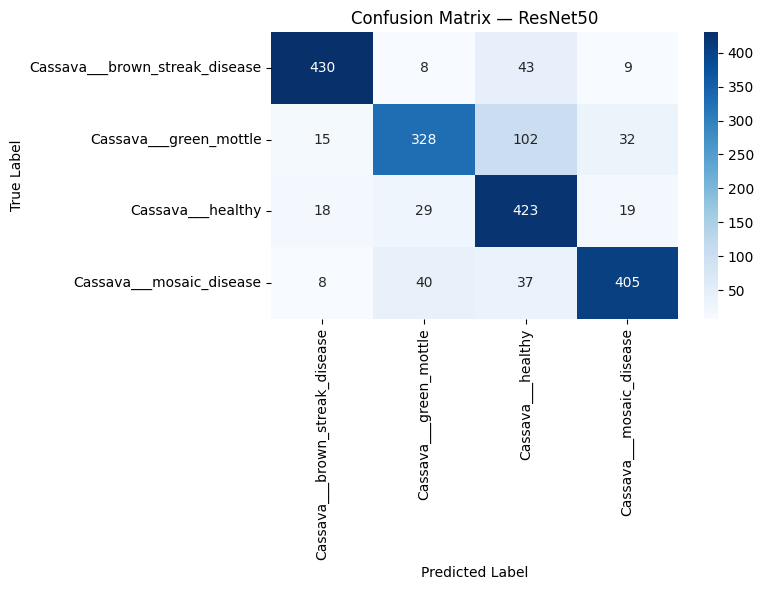

In [6]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
import seaborn as sns
import matplotlib.pyplot as plt

# ── Load your saved model ──────────────────────────────────────
model = tf.keras.models.load_model("cassava_resnet50_best_phase2.keras")

# ── Get true labels and predictions from test set ─────────────
val_data.reset()  # reset the generator to the beginning
y_pred_probs = model.predict(val_data, verbose=1)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = val_data.classes

class_names = list(val_data.class_indices.keys())

# ── Classification Report (F1, Precision, Recall) ─────────────
print(classification_report(y_true, y_pred, target_names=class_names))

# ── Confusion Matrix ───────────────────────────────────────────
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix — ResNet50")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("confusion_matrix_resnet50.png", dpi=150)
plt.show()